# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Zulfi Sam Shiddiq
- Email: zulfisamshiddi09.03@gmail.com
- Id Dicoding: zulfi_sam_shiddiq

## 1. Persiapan

### 1.1 Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from imblearn.over_sampling import SMOTE
import joblib

# Menonaktifkan peringatan (warnings) agar notebook terlihat rapi
import warnings
warnings.filterwarnings('ignore')

### 1.2 Menyiapkan data yang akan diguankan

In [2]:
df = pd.read_csv("data/data.csv", sep=";")
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2. Data Understanding

### 2.1 Mengecek informasi dasar data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [4]:
display(df.isnull().sum())
print("\nJumlah Data Duplikat:", df.duplicated().sum())

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0



Jumlah Data Duplikat: 0


In [5]:
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


Berdsasarkan observasi awal, dataset terdiri dari 4424 rows dan 37 columns. Tidak ditemukan missing values dan duplikasi data. Seluruh feature predictor dalam sudah dalam format numerik dengan kolom target `Status` bertipe object. Dari statistik deskriptif, terlihat adanya perbedaan skala yang signifikan antar feature, misalnya `Course` dengan `Inflation_rate` sehingga perlukan proses scaling

### 2.2 EDA

Jumlah data per kelas pada kolom Status:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


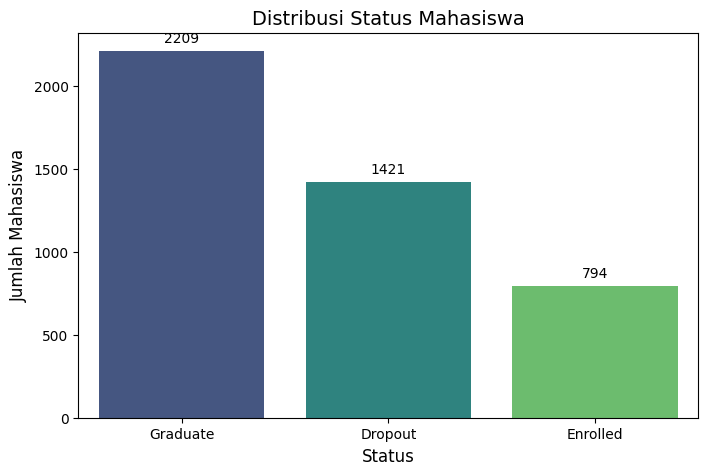

In [6]:
# Cek distribusi data
print("Jumlah data per kelas pada kolom Status:")
print(df['Status'].value_counts())

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Status', palette='viridis', order=df['Status'].value_counts().index)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title('Distribusi Status Mahasiswa', fontsize=14)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Jumlah Mahasiswa', fontsize=12)
plt.show()

Berdsasarkan observasi awal, dataset terdiri dari 4424 rows dan 37 columns. Tidak ditemukan missing values dan duplikasi data. Seluruh feature predictor dalam sudah dalam format numerik dengan kolom target `Status` bertipe object. Dari statistik deskriptif, terlihat adanya perbedaan skala yang signifikan antar feature, misalnya `Course` dengan `Inflation_rate` sehingga perlukan proses scaling. Kemudian dari distribusi data kolom `Status` memeiliki distribusi data yang tidak normal. Jumalh ketiga data bersifat imbalanced/tidak seimbang

### 2.3 Analisis Korelasi (Heatmap)

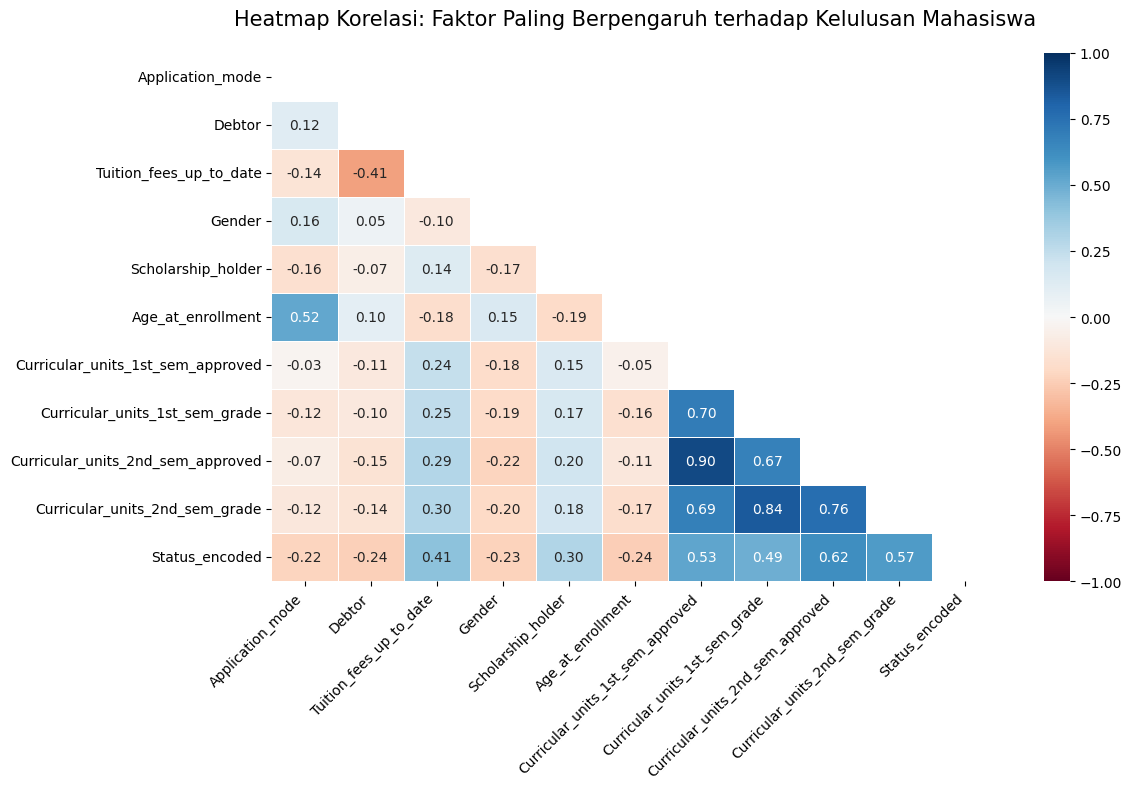

In [7]:
df_eda = df.copy()

df_eda['Status_encoded'] = df_eda['Status'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})

numeric_cols = df_eda.select_dtypes(include=[np.number])

corr_matrix = numeric_cols.corr()

target_corr = corr_matrix['Status_encoded'].drop('Status_encoded')
top_features = target_corr[abs(target_corr) > 0.2].index.tolist()

plt.figure(figsize=(12, 8))
top_corr_matrix = numeric_cols[top_features + ['Status_encoded']].corr()

mask = np.triu(np.ones_like(top_corr_matrix, dtype=bool))

sns.heatmap(top_corr_matrix, annot=True, mask=mask, cmap='RdBu', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi: Faktor Paling Berpengaruh terhadap Kelulusan Mahasiswa', fontsize=15, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Secara umum terdapat tiga faktor utama yang memiliki korelasi antar variabel, yaitu<br>
1. Faktor akademik
   - `Curricular_units_2nd_sem_approved` dan ` 1st-sem_approved` dengan jumlah mata kuliah yang lulus sangat menentukkan
   - `Curricular_units_2nd_sem_grade` dan `1st_sem_grade`, nilai yang baik berbanding lulus dengan kelulusan
2. Faktor finansial
   - `Tuition_fees_up_to_date`, menegaskan mahasiswa yang SPP nya lancar ccenderung lulus
   - `Scholarship_holder`, ini juga berbanding lulus bagi mahasiswa yang mendapatkan beasiswa aman dari dropout
   - `Debtor`, mahasiswa yang berstatus debitur/punya tunggakan sangat rentan dropout
3. Faktor demografi
   - `Age_at_enrollment`, semakin tua usia saat mendaftar, akan kecenderungan lebih tinggi untuk dropout
   - `Gender`, korelasi negatif ini menunjukkan bahwa salah satu gender memiliki tingkat dropout yang lebih tinggi, yaitu pria.

### 2.4 Deep Dive Eksplorasi Variabel Utama

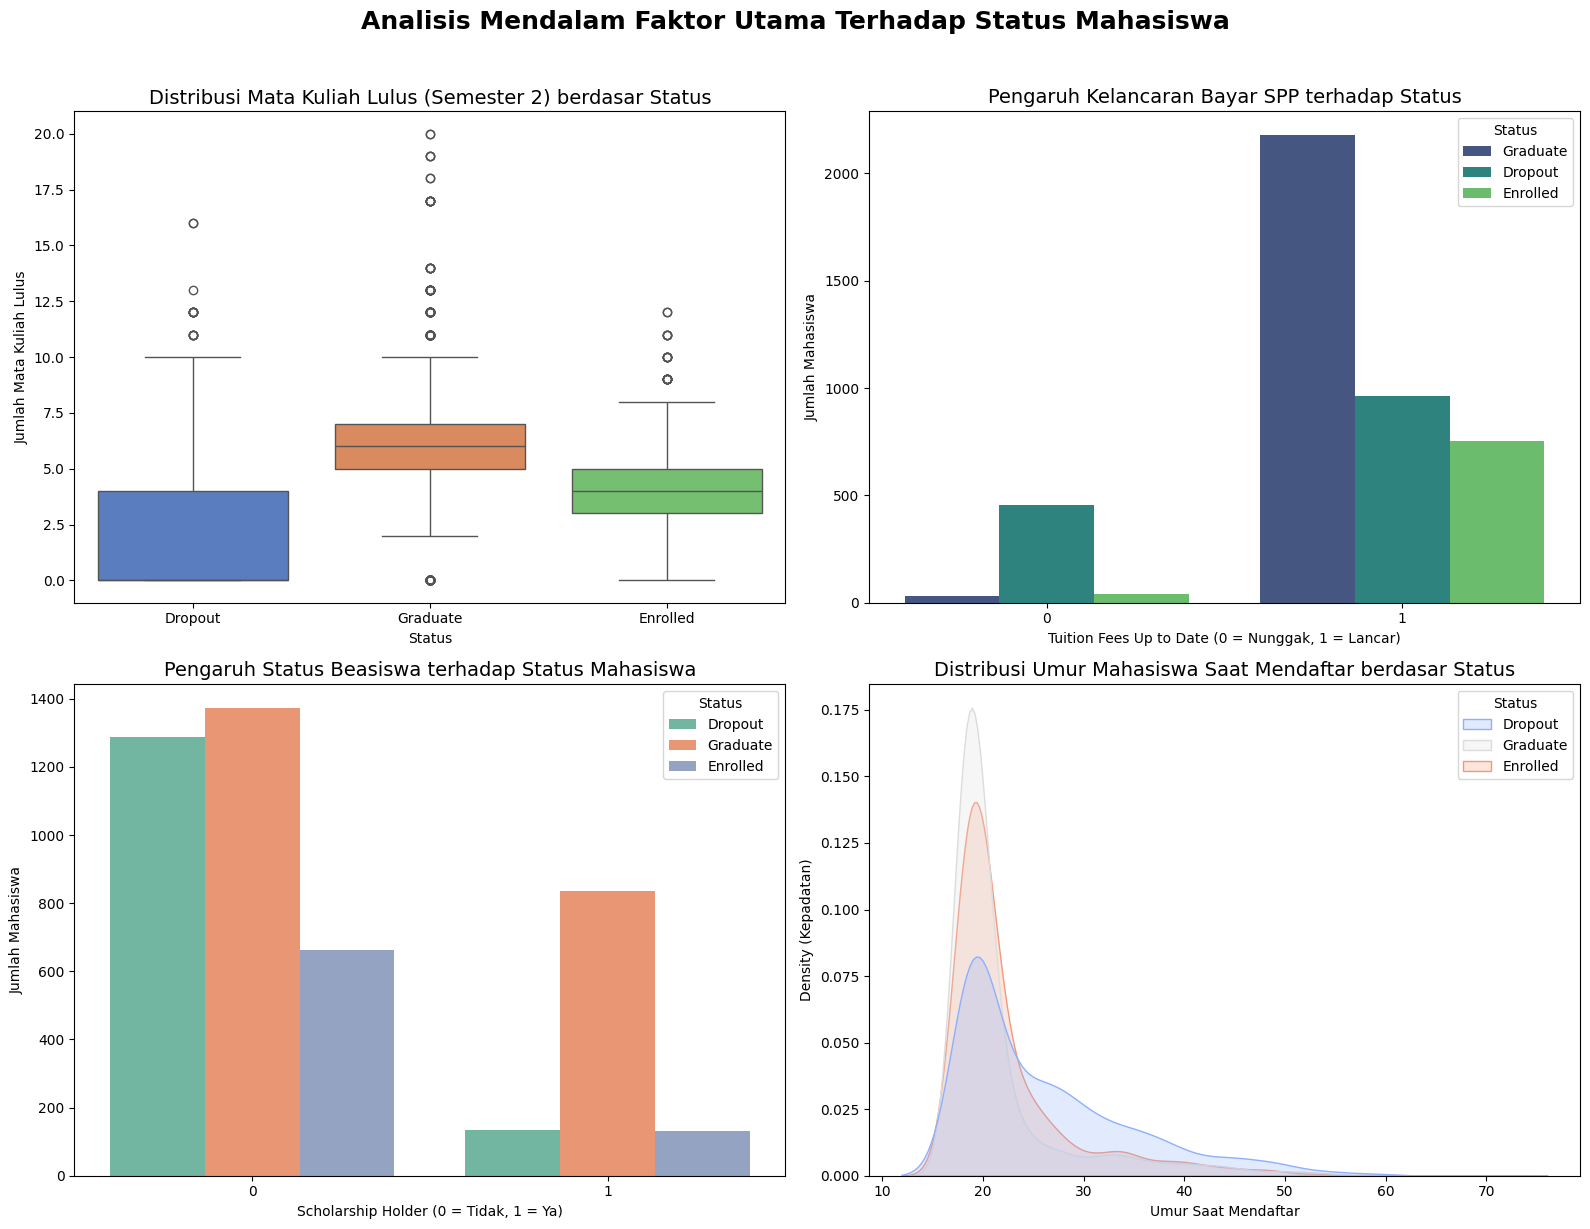

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Mendalam Faktor Utama Terhadap Status Mahasiswa', fontsize=18, fontweight='bold', y=1.02)

# 1. Faktor Akademik (Boxplot: Mata Kuliah yang Lulus di Semester 2)
sns.boxplot(ax=axes[0, 0], data=df, x='Status', y='Curricular_units_2nd_sem_approved', palette='muted')
axes[0, 0].set_title('Distribusi Mata Kuliah Lulus (Semester 2) berdasar Status', fontsize=14)
axes[0, 0].set_xlabel('Status')
axes[0, 0].set_ylabel('Jumlah Mata Kuliah Lulus')

# 2. Faktor Finansial (Countplot: Keteraturan Bayar SPP)
sns.countplot(ax=axes[0, 1], data=df, x='Tuition_fees_up_to_date', hue='Status', palette='viridis')
axes[0, 1].set_title('Pengaruh Kelancaran Bayar SPP terhadap Status', fontsize=14)
axes[0, 1].set_xlabel('Tuition Fees Up to Date (0 = Nunggak, 1 = Lancar)')
axes[0, 1].set_ylabel('Jumlah Mahasiswa')

# 3. Faktor Finansial (Countplot: Status Beasiswa)
sns.countplot(ax=axes[1, 0], data=df, x='Scholarship_holder', hue='Status', palette='Set2')
axes[1, 0].set_title('Pengaruh Status Beasiswa terhadap Status Mahasiswa', fontsize=14)
axes[1, 0].set_xlabel('Scholarship Holder (0 = Tidak, 1 = Ya)')
axes[1, 0].set_ylabel('Jumlah Mahasiswa')

# 4. Faktor Demografi (KDE Plot / Distribusi: Umur Saat Mendaftar)
sns.kdeplot(ax=axes[1, 1], data=df, x='Age_at_enrollment', hue='Status', fill=True, palette='coolwarm', common_norm=False)
axes[1, 1].set_title('Distribusi Umur Mahasiswa Saat Mendaftar berdasar Status', fontsize=14)
axes[1, 1].set_xlabel('Umur Saat Mendaftar')
axes[1, 1].set_ylabel('Density (Kepadatan)')

plt.tight_layout()
plt.show()

1. **Performa akademik :** Terdapat batasan pemisahan yang sangat tajam pada performa mahasiswa di akhir smester 2. Mahasiswa yang berstatus dorpout mayoritas memlkiki jumlah mata kuliah lulus antara 0-4. Sebaliknya, mahasiswa yang graduate memiliki penyelesaian mata kuliah yang sangat bai, mayoritas lulusan 5-7 mata kuliah. Mahasiswa yang gagal mendaatkan SKS penuh di tahun pertama adalah kandidat utama yang berisiko tinggi untuk dropout.
2. **Kepatuhan finansial SPP :** Kelancaran pembayaran UKT pada column `Tuition_fess_up_to_date` adalah indikator yang sangat krusial. Pada cluster mahasisa yang menunggak SPP (0), status dropout mendominasi secrara absolut. Sangat setikit mahasiswa yang menunggak namun bisa lulus. Masalah finansial ini merulaman penyebab dropout tercepat, universitas perlu memberikan peringatan dini atau bantuan konsultasi finansial sejak tunggakan pertama terjadi.
3. **Kepemilikan beasiswa :** Seperti yang terdapat pada kolom `Schoolarship_holder` berperan sebagai pengaman yang sangat kuat. Penerima beasiswa ini memiliki tingkat lulusan yang sangat tinggi dan rasio dropout yang sangat minim dibandinkan dengan yang tidak menerima beasiswa. Program beasiswa ini terbukti efektif mempertahankan mahasiswa hingga lulus.
4. **Usia saat mendaftar :** Distribusi usia menunjukkan bahwa mahasiswa yang lulus sangat terkonsetrasi pada usia mudia sekitar 18-20an, namun pada kurva mahasiswa dropout berada dikisaran usian 30-50am. Dengan usia dewasa atau non reguler ini memiliki tantangan yang lebih besar untuk bertahan seperti harus membagi waktu dengan pekerjaan atau keluarga, sehingga dibutuhkan fleksibilitas atau pembelajaran berdiferensiasi.

## 3. Data Preparation / Preprocessing

### 3.1 Memisahkan X dan y

In [9]:
X = df.drop(columns=['Status'])
y = df['Status']
display(X.head())
display(y.head())

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79


0     Dropout
1    Graduate
2     Dropout
3    Graduate
4    Graduate
Name: Status, dtype: object

### 3.2 Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Jumlah data latih:", X_train.shape[0])
print("Jumlah data uji:", X_test.shape[0])

Jumlah data latih: 3539
Jumlah data uji: 885


### 3.3 Scaling (Standarisasi)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Menyimpan scaler menggunakan joblib untuk digunakan di Streamlit nanti
joblib.dump(scaler, 'model/scaler.joblib')
print("Scaler berhasil disimpan di folder 'model/'")

# Menangani Imbalanced Data dengan SMOTE (Hanya pada Data Latih!)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("\nDistribusi Target sebelum SMOTE (Data Latih):")
print(y_train.value_counts())
print("\nDistribusi Target sesudah SMOTE (Data Latih):")
print(y_train_balanced.value_counts())

Scaler berhasil disimpan di folder 'model/'

Distribusi Target sebelum SMOTE (Data Latih):
Status
Graduate    1767
Dropout     1137
Enrolled     635
Name: count, dtype: int64

Distribusi Target sesudah SMOTE (Data Latih):
Status
Graduate    1767
Dropout     1767
Enrolled    1767
Name: count, dtype: int64


## 4. Modeling

Alasan menggunakan RFC karena memiliki karakteristik utama sebagai model yang tahan terhadap overfitting dan memiliki kemampuan menangani dataset tabular dengan baik.

### 4.1 Inisialisasi model RandomForest

In [12]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

#### 4.2 Model training

In [13]:
rf_model.fit(X_train_balanced, y_train_balanced)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 4.3 Prediksi

In [14]:
y_pred = rf_model.predict(X_test_scaled)

### 4.4 Save model

In [15]:
joblib.dump(rf_model, 'model/rf_model.joblib') # format .joblib supaya bisa diload saaat membuat dashboard pada stremlit
print("Model Random Forest berhasil disimpan di folder 'model/'")

Model Random Forest berhasil disimpan di folder 'model/'


## 5. Evaluation

### 5.1 Akurasis model

In [16]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model Random Forest: {accuracy * 100:.2f}%\n")

Akurasi Model Random Forest: 77.40%



### 5.2 Classification report

In [17]:
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

     Dropout       0.83      0.73      0.78       284
    Enrolled       0.53      0.52      0.52       159
    Graduate       0.83      0.89      0.86       442

    accuracy                           0.77       885
   macro avg       0.73      0.71      0.72       885
weighted avg       0.77      0.77      0.77       885



### 5.3 Visulaisasi confusion matrix

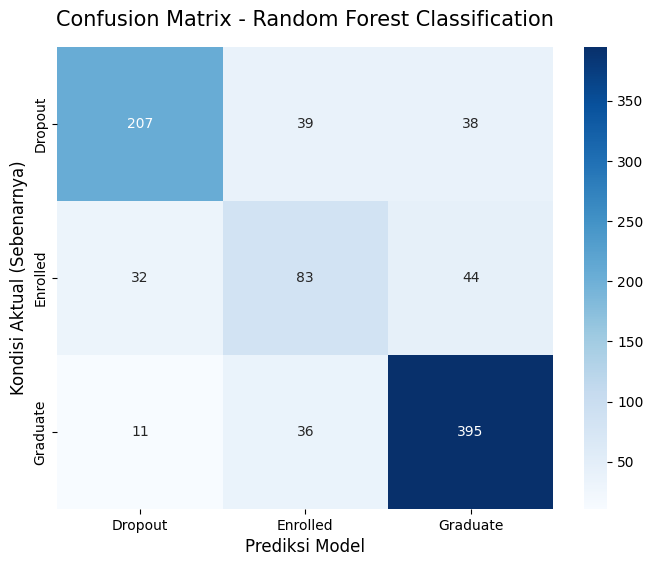

In [18]:
# Mengambil label kelas dari model
classes = rf_model.classes_
cm = confusion_matrix(y_test, y_pred, labels=classes)

# Membuat visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - Random Forest Classification', fontsize=15, pad=15)
plt.xlabel('Prediksi Model', fontsize=12)
plt.ylabel('Kondisi Aktual (Sebenarnya)', fontsize=12)
plt.show()

- **Prediksi Graduate :** Berdasarkan nilai recall, model dapat menebak mahasiswa yang lulus dengan kebenaran sebesar 89%
- **Prediksi Dropout :** Berdasarkan nilai precision, model dapat menebak mahasiswa yang dropout dengan akurat sebesar 83%
- **Prediksi Enrolled :** Status enrolled adalah fase transisi/zona abu-abu. Berdasarkan kemungkinan fakta yang terjadi, enrolled memiliki nilai bagus mirip dengan graduate dan memililiki tunggakan SPP/UKT mirip dengan dropout. Sehinggat Machine Learning terjadi kebingungan untuk membedakan kelas ini.

## Ekspor Data Tableau

In [19]:
# Menambahkan Student_ID ke dataframe asli untuk sinkronisasi dashboard
df_dashboard = df.copy()
df_dashboard.insert(0, 'Student_ID', range(1, 1 + len(df_dashboard)))

# Ekspor ke CSV
df_dashboard.to_csv('data/data_for_dashboard.csv', index=False)
print("File 'data_for_dashboard.csv' berhasil dibuat di folder data/!")

File 'data_for_dashboard.csv' berhasil dibuat di folder data/!
